In [84]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from lum_funcs import look_up_table, get_cluster, surface_2d_brightness

import matplotlib.cm as cm
import plotly.graph_objects as go
from scipy.optimize import curve_fit

In [45]:
pop_2_data = np.loadtxt(r"./pop_2_data/pos_00500_479_16_myr.txt")   
birth_epochs = pop_2_data[:,0] *1e6 
ages = pop_2_data[:,1] *1e6 
ages [ages < 1e6 ] = 1e6 # set minimum age
current_time_myr = pop_2_data[0,6]
masses = pop_2_data[:,5] #msun 


stellar_lums = look_up_table(
    stellar_ages=ages, 
    table_link='https://www.stsci.edu/science/starburst99/data/l1500_inst_e.dat', 
    column_idx=1,
    log=True)

scaled_stellar_lums = stellar_lums*1e-5 
star_positions = pop_2_data[:,2:5] # (x,y,z)

# Get One Cluster
https://github.com/erdogant/findpeaks


In [177]:
#gc_ctr = np.array([3.781448, 14.74236, 25.41285]) # pc
gc_ctr = np.array([0.8662809, -78.50676, -66.55415])
ring_width = .2
gc_rad = 15

cluster_x, cluster_y, cluster_z, cluster_lums, cluster_masses = get_cluster(
    xpos=star_positions[:,0], 
    ypos=star_positions[:,1], 
    zpos=star_positions[:,2],
    masses=masses,
    ctr_at=gc_ctr, 
    cluster_radius=gc_rad, 
    lums=scaled_stellar_lums,
    trns_coord = True
    )

In [178]:
np.sum(cluster_masses)
np.size(cluster_masses)

1794

In [179]:
d_r_2d, surface_lum_2d, counts_2d, masses_2d = surface_2d_brightness(
    xpos=cluster_x, 
    ypos=cluster_y, 
    lums=cluster_lums, 
    masses=cluster_masses, 
    dr=ring_width, 
    clust_radius=gc_rad
)
#print(d_r_2d)

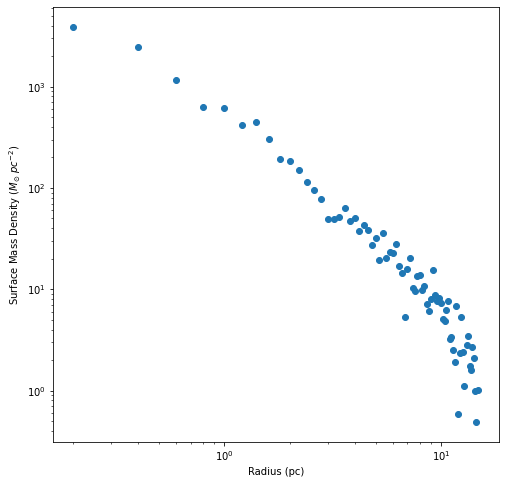

In [180]:
ring_areas = np.pi * ( (d_r_2d + ring_width)**2 - d_r_2d**2)
#print(ring_areas)
surface_lum_2d = surface_lum_2d / ring_areas 
surface_number_density =  counts_2d / ring_areas 
surface_mass_density = masses_2d/ ring_areas 

plt.figure(figsize = (8,8), )
plt.scatter(d_r_2d, surface_mass_density)
plt.ylabel(r'Surface Mass Density ($M_{\odot} \; pc^{-2}$)')
plt.xlabel('Radius (pc)')
plt.yscale('log')
plt.xscale('log')

### King Model

$ \Large f =  k \left( 
\frac{1}{\sqrt{1 + \frac{r}{r_c}^2}}      
-
\frac{1}{\sqrt{1+ \frac{r_t}{r_c}^2} }
\right)^2$

$r_c$ = core radius
$r_t$ = tidal radius
$k $= central number density
$c  = \frac{r_t}{r_c}$

https://articles.adsabs.harvard.edu/pdf/1962AJ.....67..471K
https://ned.ipac.caltech.edu/level5/Sept02/Bertin/Bertin22_2.html

In [192]:
def king_model(r, k, r_c, r_t): 
    f = k *( (1 / np.sqrt(1 + (r / r_c)**2)) - (1 / np.sqrt(1 + (r_t /r_c )**2)) )**2
    return f

def king_model_2(r, k, r_c, c): 
    f = k *( (1 / np.sqrt(1 + (r / r_c)**2)) - (1 / np.sqrt(1 + (c)**2)) )**2
    return f


# fit_params, cov_matrix = curve_fit(
#     f=king_model, 
#     xdata=d_r_2d, 
#     ydata=surface_mass_density,
#     bounds=([0,0,0], [np.inf,np.inf,np.inf]))

# fit_sigma = np.sqrt(np.diag(cov_matrix))
# print(fit_params)
# print(fit_sigma)

fit_params, cov_matrix = curve_fit(
    f=king_model_2, 
    xdata=d_r_2d, 
    ydata=surface_mass_density,
    p0 = [100, 2, 30],
    bounds=([0,0,0], [np.inf,np.inf,100]),
    
)

fit_sigma = np.sqrt(np.diag(cov_matrix))
print(fit_params)
print(fit_sigma)

[5.26423041e+03 3.57000798e-01 1.00000000e+02]
[1.10831892e+02 1.10460078e-02 1.00702567e+02]


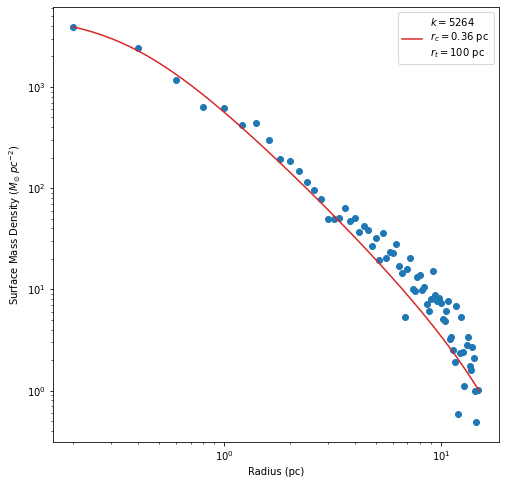

In [194]:
plt.figure(figsize = (8,8), )
plt.scatter(d_r_2d, surface_mass_density)
theory_r = np.linspace(.2,15,1000)
plt.plot(
    theory_r, 
    king_model_2(theory_r,*fit_params), 
    c='tab:red',
    label='$k = {:.0f}$ \n$r_c = {:.2f} $ pc \n$r_t = {:.0f}$ pc'.format(*fit_params))
plt.ylabel(r'Surface Mass Density ($M_{\odot} \; pc^{-2}$)')
plt.xlabel('Radius (pc)')
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [58]:
total_data = go.Scatter3d(
    x=cluster_x, 
    y=cluster_y, 
    z=cluster_z, 
    opacity=1, 
    mode='markers',
    marker=dict(color=np.log10(cluster_lums), 
                showscale=True, 
                size=1,
                colorscale='inferno',
                colorbar=dict(title='', orientation='h'), 
               ),
    )
total_data.marker.colorbar.title.side = 'right'

mean_ctr = go.Scatter3d(
    x=[float(np.mean(cluster_x))], 
    y=[float(np.mean(cluster_y))], 
    z=[float(np.mean(cluster_z))], 
    opacity=1, 
    mode='markers',
    marker=dict(color='blue', 
                size=2, 
               ),
    name='mean_ctr'
    )
mask_ctr = go.Scatter3d(
    x=[clust_ctr[0]], 
    y=[clust_ctr[1]], 
    z=[clust_ctr[2]], 
    opacity=1, 
    mode='markers',
    marker=dict(color='red', 
                size=2, 
               ),
    name='mask_ctr'
    )
median_ctr = go.Scatter3d(
    x=[float(np.median(cluster_x))], 
    y=[float(np.median(cluster_y))], 
    z=[float(np.median(cluster_z))], 
    opacity=1, 
    mode='markers',
    marker=dict(color='green', 
                size=2, 
               ),
    name='median_ctr'
    )
fig=go.Figure()
fig.add_trace(total_data)
# fig.add_trace(mean_ctr)
#fig.add_trace(mask_ctr)
fig.add_trace(median_ctr)



#fig=go.Figure(data=total_data,  )

fig.update_layout(title = 't = {:.3f}Myr'.format(current_time_myr), 
                  template='plotly_dark', 
                  width=700, 
                  height=600,
                  scene = dict(
                  xaxis = dict(nticks=3, ),
                  yaxis = dict(nticks=3, showgrid=False),
                  zaxis = dict(nticks=3, showgrid=False),
                  ),
                 )
fig.update_scenes(xaxis_title=dict(text='x (pc)'),
                  yaxis_title=dict(text='y (pc)'),
                  zaxis_title=dict(text='z (pc)'),
                  )
fig.show()